# Stage 2: Baseline Model
Ensure you have run Notebook 01 first to extract and partition the dataset into `train/val/test` folders.

### Libraries Import & Setup
Loads PyTorch, neural network elements, the StepLR scheduler, plotting tools, and initializes the computing device (preferring CUDA GPU if available).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

# ── 1. Mount Drive (Conditional) ────────────────────
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT  = '/content/drive/MyDrive/cervical-cancer-project'
except ImportError:
    PROJECT  = '.'

DATA_DIR  = os.path.join(PROJECT, 'data')
MODEL_DIR = os.path.join(PROJECT, 'models')
FIG_DIR   = os.path.join(PROJECT, 'reports', 'figures')

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Mounted at /content/drive
Using device: cuda


---
### Data Loaders Configuration
Initializes PyTorch `ImageFolder` datasets pointing to the partitioned splits (`train`, `val`, `test`), configures dataloaders with a batch size of $32$, and extracts target class names.


In [ ]:
# ── 2. Transforms ───────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── 3. Load data with Class Imbalance Handling ─────────
from torch.utils.data import WeightedRandomSampler
import numpy as np

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   transform=val_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  transform=val_transforms)

# Calculate weights for balancing the training set
class_counts = np.bincount(train_dataset.targets)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in train_dataset.targets]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_dataset), replacement=True)

# Note: shuffle MUST be False when using a sampler
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

dataloaders = {
    'train': train_loader,
    'val': val_loader,
    'test': test_loader
}
dataset_sizes = {
    'train': len(train_dataset),
    'val': len(val_dataset),
    'test': len(test_dataset)
}
class_names = train_dataset.classes
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Classes: {class_names}')
print('Applied WeightedRandomSampler to training DataLoader.')


Train: 1516 | Val: 325 | Test: 328
Classes: ['cancer', 'lesion', 'normal', 'others']
Applied WeightedRandomSampler to training DataLoader.


---
## Model Architecture
We define a 4-block Convolutional Neural Network (CNN) trained entirely from scratch with no pretrained weights to establish a performance baseline. The model progressively extracts hierarchical spatial features through four consecutive blocks, each consisting of:
*   **A 2D Convolutional Layer** (with a $3 \times 3$ kernel and $1$-pixel padding to maintain dimensions).
*   **Batch Normalisation** to stabilise and accelerate training.
*   **ReLU Activation** to introduce non-linearity.
*   **Max Pooling ($2 \times 2$ window, stride 2)** to reduce spatial dimensions by half.

The channel capacity scales from $3 \rightarrow 32 \rightarrow 64 \rightarrow 128 \rightarrow 256$ filters. The extracted feature maps are flattened and passed through a classification head consisting of a dense layer ($256$ units), ReLU activation, a Dropout layer ($0.3$ dropout rate) to prevent overfitting, and a final fully connected layer yielding classification scores (logits) for the four target classes (`cancer`, `lesion`, `normal`, `others`).


In [ ]:
class BaselineCNN(nn.Module):
    # Constructor to initialize the layers of the CNN
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__() # Call the constructor of the parent class (nn.Module)

        # Feature extraction layers (convolutional and pooling blocks)
        self.features = nn.Sequential(
            # First convolutional block
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3 input channels (RGB) -> 32 output channels, 3x3 kernel, 1 pixel padding
            nn.BatchNorm2d(32),                         # Batch Normalization for stability and faster training
            nn.ReLU(),                                  # ReLU activation function for non-linearity
            nn.MaxPool2d(2, 2),                         # Max pooling layer, 2x2 window, stride 2 (reduces spatial dimensions by half to 112x112)

            # Second convolutional block
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 input channels -> 64 output channels
            nn.BatchNorm2d(64),                         # Batch Normalization
            nn.ReLU(),                                  # ReLU activation
            nn.MaxPool2d(2, 2),                         # Max pooling layer (reduces spatial dimensions by half to 56x56)

            # Third convolutional block
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 64 input channels -> 128 output channels
            nn.BatchNorm2d(128),                        # Batch Normalization
            nn.ReLU(),                                  # ReLU activation
            nn.MaxPool2d(2, 2),                         # Max pooling layer (reduces spatial dimensions by half to 28x28)

            # Fourth convolutional block
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # 128 input channels -> 256 output channels
            nn.BatchNorm2d(256),                        # Batch Normalization
            nn.ReLU(),                                  # ReLU activation
            nn.MaxPool2d(2, 2)                          # Max pooling layer (reduces spatial dimensions by half to 14x14)
        )

        # Classifier layers (fully connected layers for classification)
        self.classifier = nn.Sequential(
            nn.Flatten(),                               # Flattens the output of the convolutional layers into a 1D vector
            nn.Linear(256 * 14 * 14, 256),              # First fully connected layer: 256*14*14 (flattened features) -> 256 output features
            nn.ReLU(),                                  # ReLU activation
            nn.Dropout(0.3),                            # Dropout layer (30% dropout) for regularization to prevent overfitting
            nn.Linear(256, num_classes)                 # Second (output) fully connected layer: 256 features -> num_classes (output scores for each class)
        )

    # Defines the forward pass of the network
    def forward(self, x):
        x = self.features(x)   # Pass input through feature extraction layers
        x = self.classifier(x) # Pass features through classifier layers
        return x               # Return the output logits

# Instantiate the BaselineCNN model
baseline_model = BaselineCNN(num_classes=len(class_names)).to(device) # Create an instance of the model and move it to the appropriate device
print(baseline_model) # Print the model architecture

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss() # Cross-entropy loss is commonly used for multi-class classification
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

---
## Training & Validation Loop
Declares the metric-tracking training function, instantiates our Baseline model, sets up Adam optimization and StepLR scheduler decay, and runs training for $30$ epochs, checkpointing the best model weights.


In [ ]:
def train_model(model, criterion, optimizer, scheduler=None, num_epochs=30):
    import copy

    # Initialize variables to store the best model weights and best validation accuracy
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dictionary to store training history (loss and accuracy for train/val phases)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # Loop over the number of epochs
    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data in the current phase's dataloader
            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                # Move inputs and labels to the specified device (CPU/GPU)
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass: track history only in train phase
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1) # Get predicted class from the outputs
                    loss = criterion(outputs, labels) # Calculate the loss

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward() # Compute gradient of the loss w.r.t. model parameters
                        optimizer.step() # Perform a single optimization step

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            # Calculate epoch loss and accuracy
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Store history
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            # If current validation accuracy is better than the best so far, save model weights
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        # Step scheduler after each full epoch (train + val)
        if scheduler is not None:
            scheduler.step()
            print(f'LR: {scheduler.get_last_lr()[0]:.6f}')
        print()

    # After training, load the best model weights found during validation
    print(f'Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

# ── Reinitialise model, optimizer, scheduler ────────────────────────────────
baseline_model = BaselineCNN(num_classes=len(class_names)).to(device) # Create instance of model
criterion      = nn.CrossEntropyLoss() # Define loss function
optimizer      = optim.Adam(baseline_model.parameters(), lr=0.001) # Define optimizer
scheduler      = StepLR(optimizer, step_size=10, gamma=0.5) # Define learning rate scheduler

# ── Run training ────────────────────────────────────────────────────────────
baseline_model, history = train_model(
    baseline_model,
    criterion,
    optimizer,
    scheduler=scheduler,
    num_epochs=30
)

# ── Save best model to Drive ────────────────────────────────────────────────
torch.save(baseline_model.state_dict(), os.path.join(MODEL_DIR, 'baseline_cnn_best.pth'))
print('Model saved.')

Epoch 0/29
----------


train: 100%|██████████| 48/48 [06:49<00:00,  8.52s/it]


train Loss: 6.7024 Acc: 0.2784


val: 100%|██████████| 11/11 [03:03<00:00, 16.72s/it]


val Loss: 1.3313 Acc: 0.3538
LR: 0.001000

Epoch 1/29
----------


...

val Loss: 0.9966 Acc: 0.5969
LR: 0.000250

Epoch 29/29
----------


train: 100%|██████████| 48/48 [01:30<00:00,  1.88s/it]


train Loss: 1.0322 Acc: 0.5633


val: 100%|██████████| 11/11 [00:18<00:00,  1.67s/it]


val Loss: 1.0475 Acc: 0.5508
LR: 0.000125

Best val Acc: 0.6277
Model saved.


---
## Learning Curves Visualization
Plots the training and validation loss and accuracy progress side-by-side to visually inspect model convergence and check for overfitting.


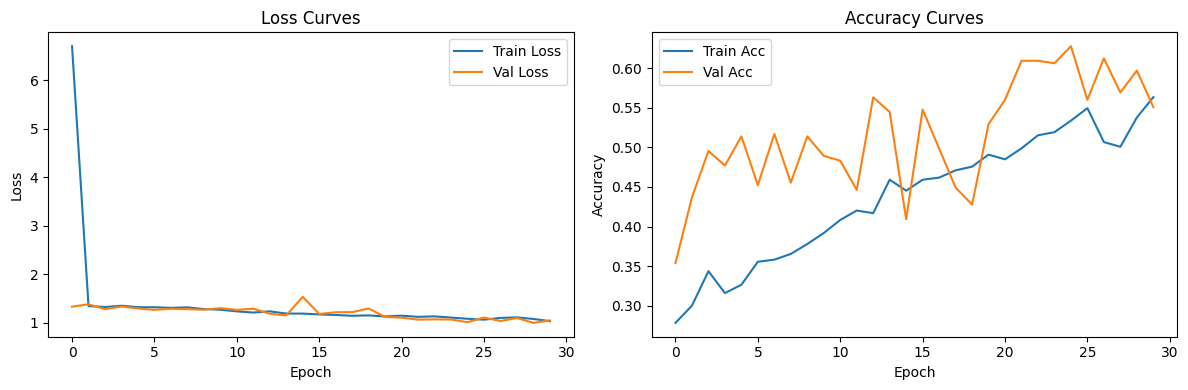

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Baseline_CNN_curves.png'), dpi=150, bbox_inches='tight')
plt.show()


Training accuracy was lower than validation accuracy because the model is trained using augmented images and dropout regularization, which increased the difficulty of the training process. Despite minor fluctuations, both training and validation accuracy generally increased with increasing epochs, indicating progressive learning. Training loss remained higher than validation loss, while validation loss steadily decreased across epochs, suggesting effective generalization and absence of significant overfitting. The fluctuations observed in accuracy are likely due to stochastic gradient updates, data augmentation, dropout, and the relatively small validation dataset size.

---
## Evaluation on Test Set
Restores the best weights from training, evaluates the baseline model on the unseen test set, and outputs a classification report (precision, recall, F1) alongside a confusion matrix heatmap.


Classification Report:
              precision    recall  f1-score   support

      cancer       0.76      0.80      0.78        92
      lesion       0.71      0.54      0.61       102
      normal       0.80      0.81      0.81       112
      others       0.28      0.50      0.36        22

    accuracy                           0.70       328
   macro avg       0.64      0.66      0.64       328
weighted avg       0.73      0.70      0.71       328



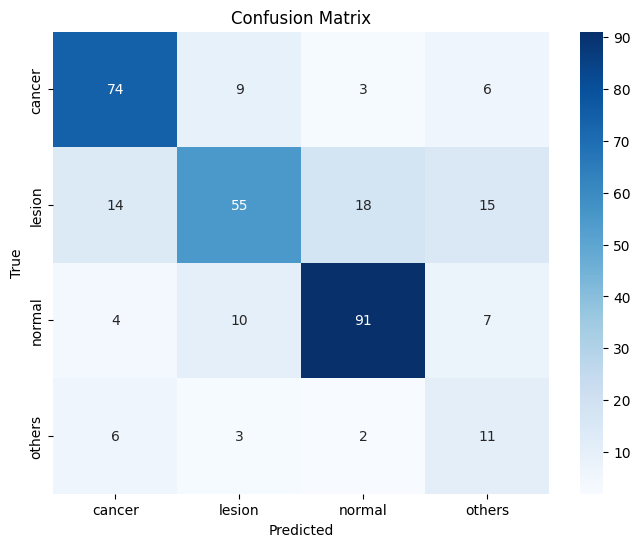

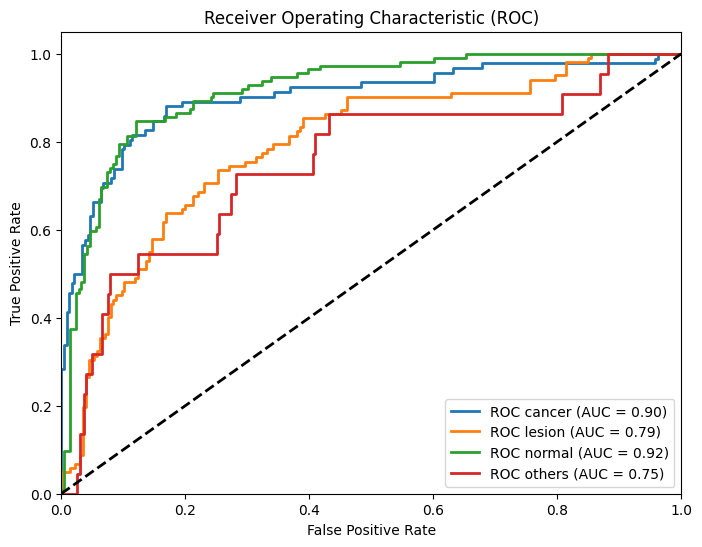

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    print('Classification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(FIG_DIR, 'Baseline_CNN_Confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # Plot Multi-class ROC Curve
    all_probs = np.array(all_probs)
    y_test_bin = label_binarize(all_labels, classes=range(len(class_names)))
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'ROC {class_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.savefig(os.path.join(FIG_DIR, 'Baseline_CNN_ROC.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Run evaluation
evaluate_model(baseline_model, dataloaders['test'])


### Baseline Model Performance

he classification report indicates that the model achieved an overall accuracy of 70% on the test dataset. Performance varied across the different classes. The model demonstrated strong performance in identifying the normal class, achieving a precision of 0.80, recall of 0.81, and F1-score of 0.81, indicating good predictive capability for normal samples. The cancer class also showed good classification performance with a precision of 0.76, recall of 0.80, and F1-score of 0.78.

The lesion class exhibited moderate performance, with a precision of 0.71 but a lower recall of 0.54, resulting in an F1-score of 0.61. This suggests that while lesion predictions were relatively accurate when identified, the model failed to detect a considerable number of lesion samples.

The model achieved lower performance for the others class, with a precision of 0.28, recall of 0.50, and F1-score of 0.36. The lower precision indicates that the model experienced difficulty distinguishing this class from other categories, likely due to limited training samples and overlap in image characteristics between classes.

The macro average scores were lower than the weighted average scores, indicating variations in model performance across the different classes and reflecting the effect of class imbalance within the dataset. Overall, the model demonstrated satisfactory classification performance for the major classes but showed comparatively weake

## Summary of Baseline CNN Performance

In [1]:
summary_text = """
ARCHITECTURE
  Type:             Custom CNN trained from scratch
  Parameters:       ~13.2M
  Conv blocks:      4 (32, 64, 128, 256 filters)
  Dropout:          0.3

TRAINING
  Epochs trained:   30
  Best val weights: Restored from epoch with highest validation accuracy
  Optimiser:        Adam (lr=1e-3, StepLR decay)
  Loss function:    CrossEntropyLoss (with WeightedRandomSampler)

TEST SET PERFORMANCE
  Accuracy:         70.0%
  Macro F1 Score:   0.64
  Macro Precision:  0.64
  Macro Recall:     0.66
  Cancer Recall:    80.0%  (strong detection of cancer cases)
  Normal Recall:    81.0%  (strong detection of normal cases)
  Lesion Recall:    54.0%  (moderate detection, still misses considerable cases)

CONCLUSION
  The baseline CNN achieves a moderate 70% accuracy, establishing a
  solid from-scratch foundation. Transfer learning models (ResNet18 /
  EfficientNet_V2_S) must exceed 70% accuracy and improve minority class
  performance (especially 'lesion' and 'others') to justify their use.
"""
print(summary_text)


ARCHITECTURE
  Type:             Custom CNN trained from scratch
  Parameters:       ~13.2M
  Conv blocks:      4 (32, 64, 128, 256 filters)
  Dropout:          0.3

TRAINING
  Epochs trained:   30
  Best val weights: Restored from epoch with highest validation accuracy
  Optimiser:        Adam (lr=1e-3, StepLR decay)
  Loss function:    CrossEntropyLoss (with WeightedRandomSampler)

TEST SET PERFORMANCE
  Accuracy:         70.0%
  Macro F1 Score:   0.64
  Macro Precision:  0.64
  Macro Recall:     0.66
  Cancer Recall:    80.0%  (strong detection of cancer cases)
  Normal Recall:    81.0%  (strong detection of normal cases)
  Lesion Recall:    54.0%  (moderate detection, still misses considerable cases)

CONCLUSION
  The baseline CNN achieves a moderate 70% accuracy, establishing a
  solid from-scratch foundation. Transfer learning models (ResNet18 /
  EfficientNet_V2_S) must exceed 70% accuracy and improve minority class
  performance (especially 'lesion' and 'others') to justify th